## Lasso Regression

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Data/real_data/real_combine.csv')

In [4]:
df.head()

,T,TM,Tm,SLP,H,VV,V,VM,PM2.5
0,7.4,9.8,4.8,1017.6,93.0,0.5,4.3,9.4,219.720833
1,7.8,12.7,4.4,1018.5,87.0,0.6,4.4,11.1,182.187500
2,7.6,15.7,2.7,1017.4,80.0,0.6,0.9,7.6,115.287500
3,6.9,15.7,2.9,1016.4,85.0,0.6,2.8,11.1,0.000000
4,6.6,12.6,1.9,1018.5,87.0,0.6,2.8,11.1,12.379167


In [5]:
### check for null values

df.isnull()

,T,TM,Tm,SLP,H,VV,V,VM,PM2.5
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
1415,False,False,False,False,False,False,False,False,False
1416,False,False,False,False,False,False,False,False,False
1417,False,False,False,False,False,False,False,False,False
1418,False,False,False,False,False,False,False,False,False


<Axes: >

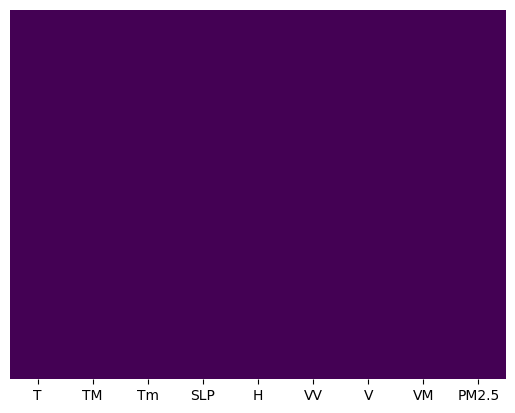

In [6]:
sns.heatmap(df.isnull(), yticklabels = False, cbar = False, cmap = 'viridis')

In [7]:
df.isnull().sum()

T        0
TM       0
Tm       0
SLP      0
H        0
VV       0
V        0
VM       0
PM2.5    1
dtype: int64

In [8]:
df = df.dropna()

In [9]:
X=df.iloc[:,:-1] ## independent features
y=df.iloc[:,-1] ## dependent features

In [10]:
## check null values
X.isnull()

,T,TM,Tm,SLP,H,VV,V,VM
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
1415,False,False,False,False,False,False,False,False
1416,False,False,False,False,False,False,False,False
1417,False,False,False,False,False,False,False,False
1418,False,False,False,False,False,False,False,False


In [11]:
y.isnull()

0       False
1       False
2       False
3       False
4       False
        ...  
1415    False
1416    False
1417    False
1418    False
1419    False
Name: PM2.5, Length: 1419, dtype: bool

In [12]:
df.head()

## there is no categorical variables

,T,TM,Tm,SLP,H,VV,V,VM,PM2.5
0,7.4,9.8,4.8,1017.6,93.0,0.5,4.3,9.4,219.720833
1,7.8,12.7,4.4,1018.5,87.0,0.6,4.4,11.1,182.187500
2,7.6,15.7,2.7,1017.4,80.0,0.6,0.9,7.6,115.287500
3,6.9,15.7,2.9,1016.4,85.0,0.6,2.8,11.1,0.000000
4,6.6,12.6,1.9,1018.5,87.0,0.6,2.8,11.1,12.379167


In [13]:
df.info()

## all datatypes are float type.

<class 'pandas.core.frame.DataFrame'>
Index: 1419 entries, 0 to 1419
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   T       1419 non-null   float64
 1   TM      1419 non-null   float64
 2   Tm      1419 non-null   float64
 3   SLP     1419 non-null   float64
 4   H       1419 non-null   float64
 5   VV      1419 non-null   float64
 6   V       1419 non-null   float64
 7   VM      1419 non-null   float64
 8   PM2.5   1419 non-null   float64
dtypes: float64(9)
memory usage: 110.9 KB


In [14]:
'''
## If the feature datatypes are not float or int:
for col in df.columns[:-1]:  ## excluding the target variable
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col])  # Convert to numeric
'''

"\n## If the feature datatypes are not float or int:\nfor col in df.columns[:-1]:  ## excluding the target variable\n    if df[col].dtype == 'object':\n        df[col] = pd.to_numeric(df[col])  # Convert to numeric\n"

In [15]:
df.isnull().sum()

T        0
TM       0
Tm       0
SLP      0
H        0
VV       0
V        0
VM       0
PM2.5    0
dtype: int64

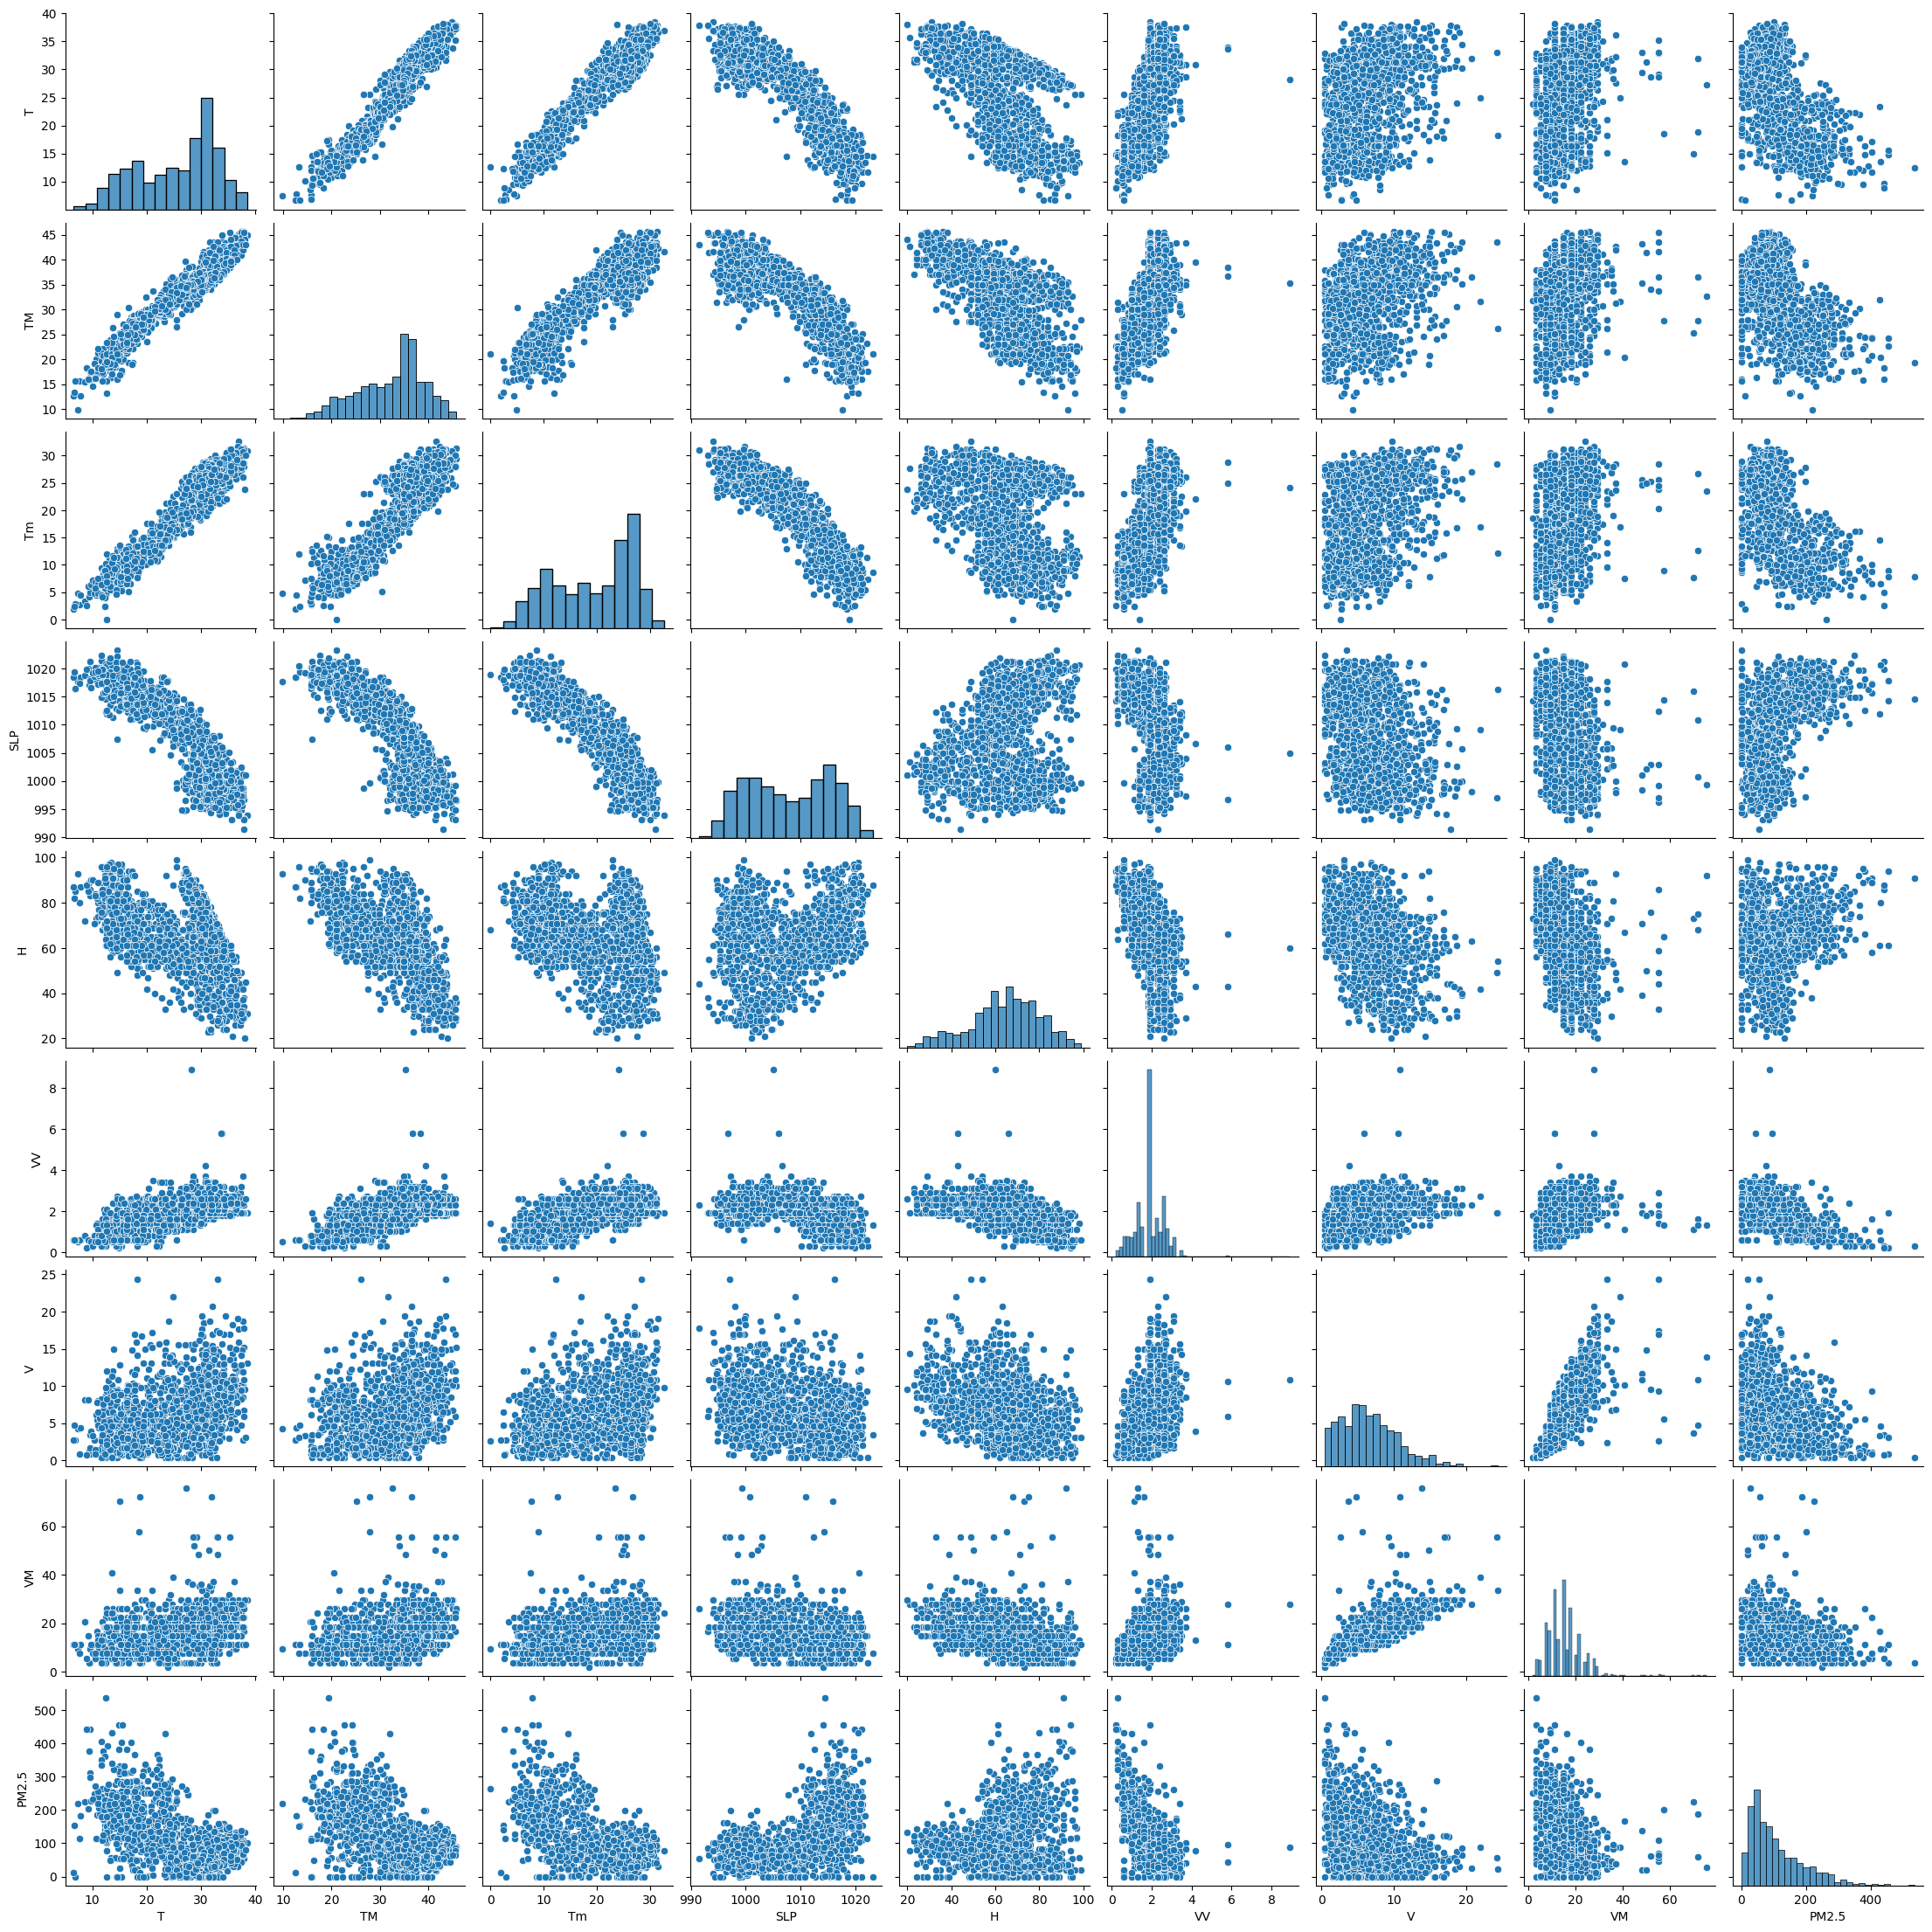

In [ ]:
## Checking for correlation

sns.pairplot(df)

## Observe that independent and dependent variables are not showing any strong correlation.
## Hence linear regression is not a good choice for this dataset. 


In [17]:
df.corr()

,T,TM,Tm,SLP,H,VV,V,VM,PM2.5
T,1.000000,0.964147,0.958485,-0.887549,-0.516583,0.614719,0.338846,0.264579,-0.609425
TM,0.964147,1.000000,0.891988,-0.831472,-0.601040,0.591047,0.323469,0.272978,-0.542796
Tm,0.958485,0.891988,1.000000,-0.912176,-0.309849,0.548203,0.324904,0.243516,-0.648294
SLP,-0.887549,-0.831472,-0.912176,1.000000,0.272395,-0.472720,-0.333361,-0.269637,0.591308
H,-0.516583,-0.601040,-0.309849,0.272395,1.000000,-0.494838,-0.395116,-0.335445,0.175734
VV,0.614719,0.591047,0.548203,-0.472720,-0.494838,1.000000,0.409247,0.324199,-0.599549
V,0.338846,0.323469,0.324904,-0.333361,-0.395116,0.409247,1.000000,0.739446,-0.353157
VM,0.264579,0.272978,0.243516,-0.269637,-0.335445,0.324199,0.739446,1.000000,-0.259054
PM2.5,-0.609425,-0.542796,-0.648294,0.591308,0.175734,-0.599549,-0.353157,-0.259054,1.000000


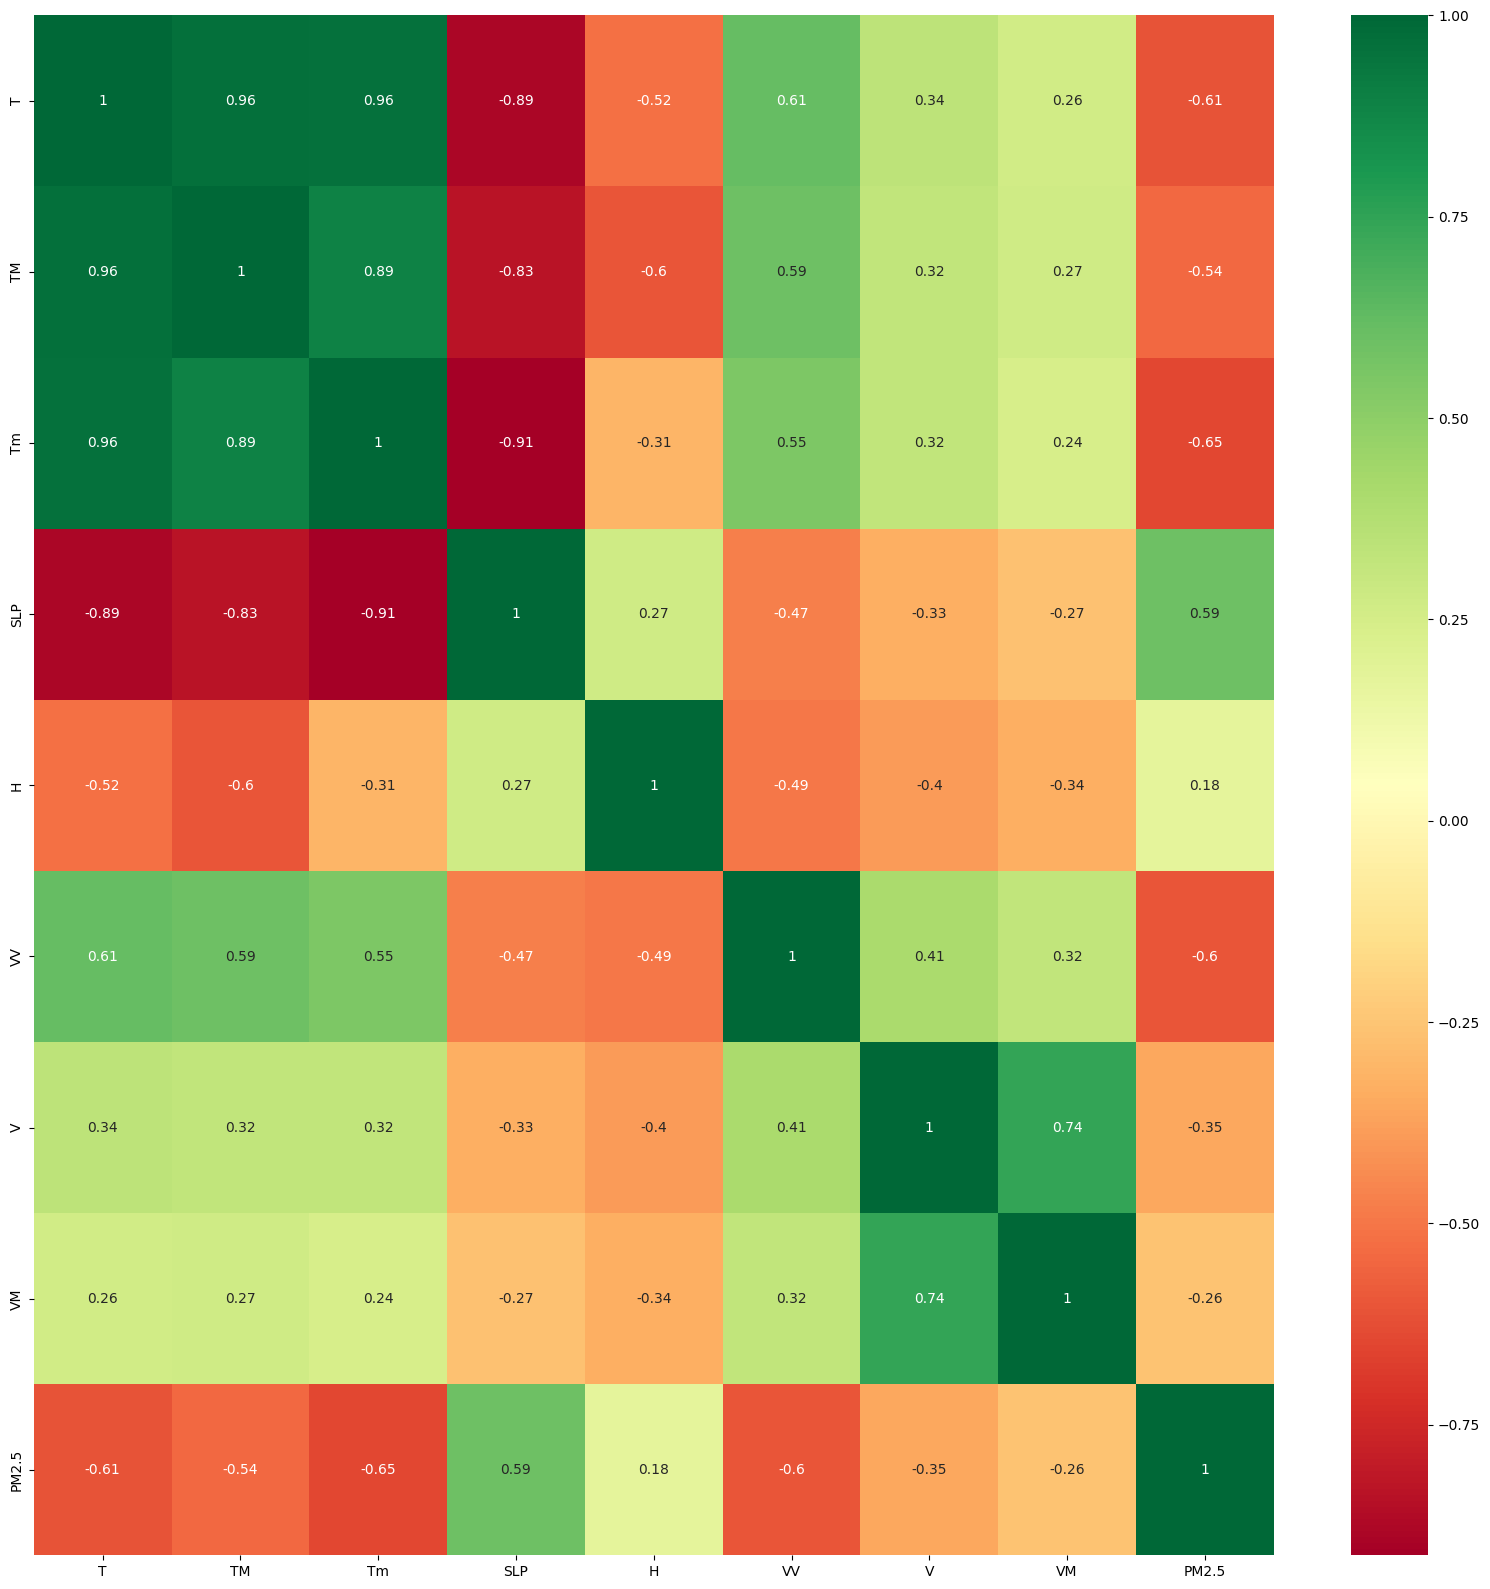

In [18]:
## correlation heatmap

corrmat = df.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(20,20))
g = sns.heatmap(df[top_corr_features].corr(), annot=True, cmap='RdYlGn')

In [19]:
corrmat.index

Index(['T', 'TM', 'Tm', 'SLP', 'H', 'VV', 'V', 'VM', 'PM2.5'], dtype='object')

In [20]:
## Checking feature importance using ExtraTreesRegressor

from sklearn.ensemble import ExtraTreesRegressor
model = ExtraTreesRegressor()
model.fit(X,y)

ExtraTreesRegressor()

In [21]:
print(model.feature_importances_)

[0.13833514 0.0851091  0.23157007 0.10739317 0.08175179 0.26158534
 0.05131718 0.04293822]


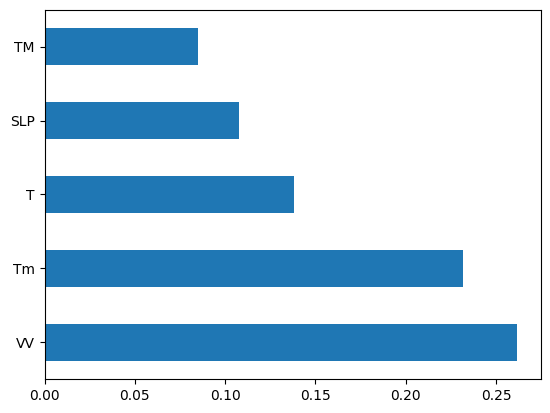

In [23]:
## plot it
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(5).plot(kind='barh')
plt.show()

In [24]:
### here in our case we wont be doing feature selection,
## as there is less number of features.

C:\Users\sudhi\AppData\Local\Temp\ipykernel_22652\254292454.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y)


<Axes: xlabel='PM2.5', ylabel='Density'>

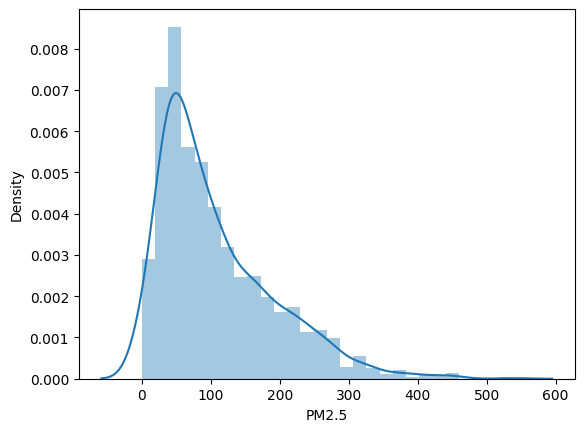

In [25]:
## Now we will see the distribution of the target variable
sns.distplot(y)

In [26]:
## Recap till now:
# 1. We have checked for null values and removed them.
# 2. We have checked for multicollinearity and correleation and 
# observed that there is no strong correlation between independent 
# and dependent variables.
# 3. We have checked for feature importance using ExtraTreesRegressor.
# 4. We have checked for distribution of the target variable.

In [27]:
## Model building

## Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 0)


In [28]:
### Comparison of Linear, Ridge and Lasso regression

In [29]:
# Linear regression

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression


In [30]:
lin_regressor = LinearRegression()
mse = cross_val_score(lin_regressor, X, y, scoring = 'neg_mean_squared_error', cv = 5)
mean_mse = np.mean(mse)
print(mean_mse)

-3636.514406210588


In [31]:
## Ridge regression

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [32]:
ridge = Ridge()
parameters = {'alpha': [1e-15, 1e-10, 1e-8, 1e-3, 1e-2, 1, 5, 10, 20, 30, 35, 40, 50, 70, 90, 100]}
ridge_regressor = GridSearchCV(ridge, parameters, scoring = 'neg_mean_squared_error', cv = 5)
ridge_regressor.fit(X,y)


GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 0.001, 0.01, 1, 5, 10,
                                   20, 30, 35, 40, 50, 70, 90, 100]},
             scoring='neg_mean_squared_error')

In [33]:
print(ridge_regressor.best_params_)
print(ridge_regressor.best_score_)

{'alpha': 100}
-3583.031104278285


In [34]:
## Lasso regressor

from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV


In [35]:
lasso = Lasso()
parameters = {'alpha': [1e-15, 1e-10, 1e-8, 1e-3, 1e-2, 1, 5, 10, 20, 30, 35, 40, 50, 70, 90, 100]}
lasso_regressor = GridSearchCV(lasso, parameters, scoring = 'neg_mean_squared_error', cv = 5)
lasso_regressor.fit(X, y)
print(lasso_regressor.best_params_)
print(lasso_regressor.best_score_)

d:\Machine learning and AI\End to end projects\AQI\venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.915e+06, tolerance: 8.549e+02
  model = cd_fast.enet_coordinate_descent(
d:\Machine learning and AI\End to end projects\AQI\venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.677e+06, tolerance: 7.475e+02
  model = cd_fast.enet_coordinate_descent(
d:\Machine learning and AI\End to end projects\AQI\venv\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

{'alpha': 5}
-3590.1709570325247


In [36]:
## Model evaluation

In [37]:
prediction = lasso_regressor.predict(X_test)

C:\Users\sudhi\AppData\Local\Temp\ipykernel_22652\1520944062.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test-prediction)


<Axes: xlabel='PM2.5', ylabel='Density'>

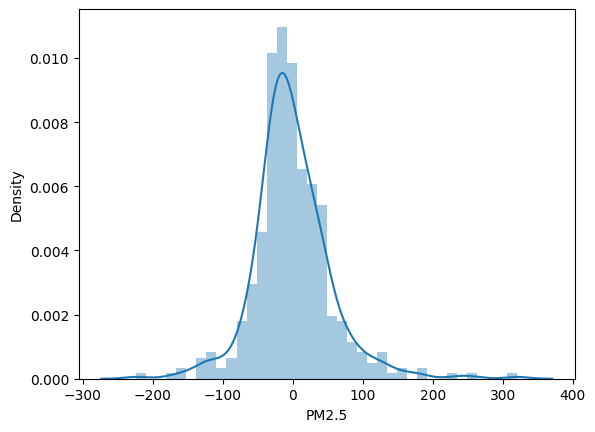

In [38]:
sns.distplot(y_test-prediction)

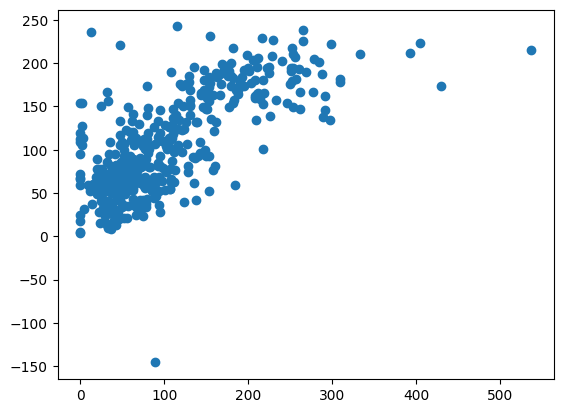

In [39]:

plt.scatter(y_test,prediction)

In [40]:
## Regression evaluation metrics

In [41]:

from sklearn import metrics

In [42]:

print('MAE:', metrics.mean_absolute_error(y_test, prediction))
print('MSE:', metrics.mean_squared_error(y_test, prediction))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, prediction)))

MAE: 38.94950162242251
MSE: 3100.039359872026
RMSE: 55.67799708926342


In [43]:

import pickle 

In [44]:

# open a file, where you want to store the data
file = open('lasso_regression_model.pkl', 'wb')

# dump information to that file
pickle.dump(lasso_regressor, file)